In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("diabetes.csv")   
print("Dataset loaded successfully!")


Dataset loaded successfully!


In [24]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:\n", df.head())
print("\nData Types:\n", df.dtypes)

Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

First 5 rows:
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Data Types:
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness 

In [25]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [26]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [27]:
print(df.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

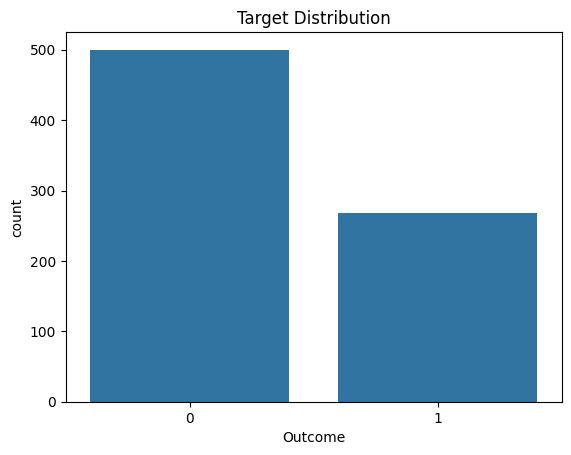

Outcome
0    500
1    268
Name: count, dtype: int64


In [28]:
sns.countplot(x=df["Outcome"])   
plt.title("Target Distribution")
plt.show()

print(df["Outcome"].value_counts())

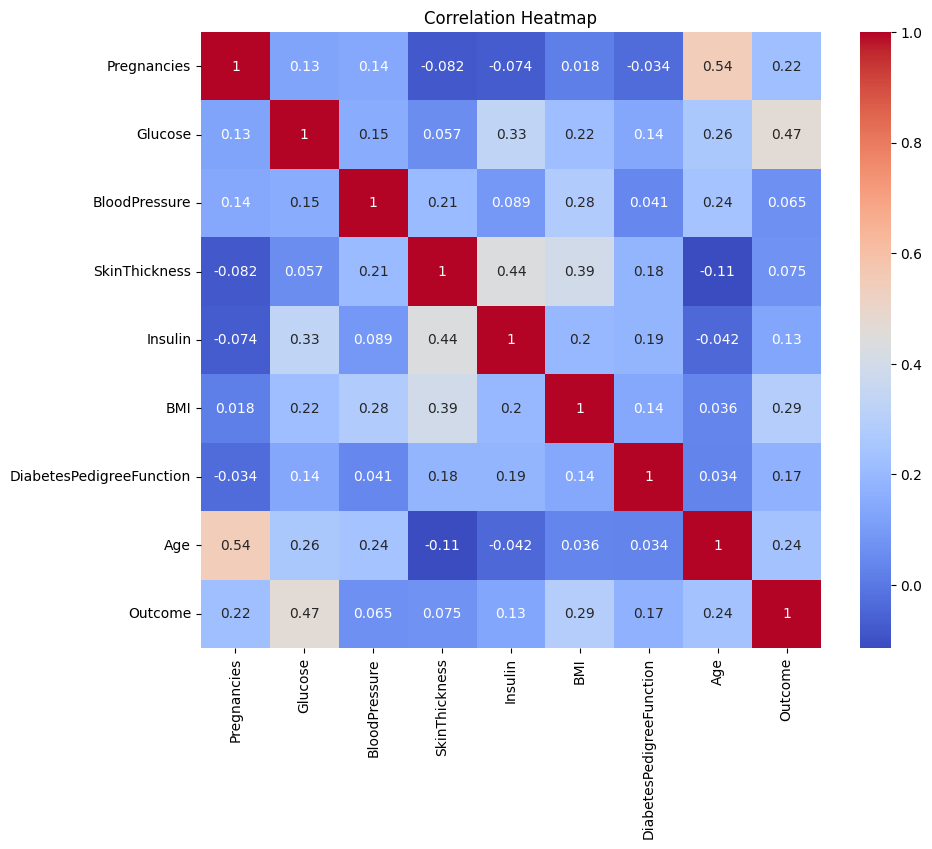

In [29]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

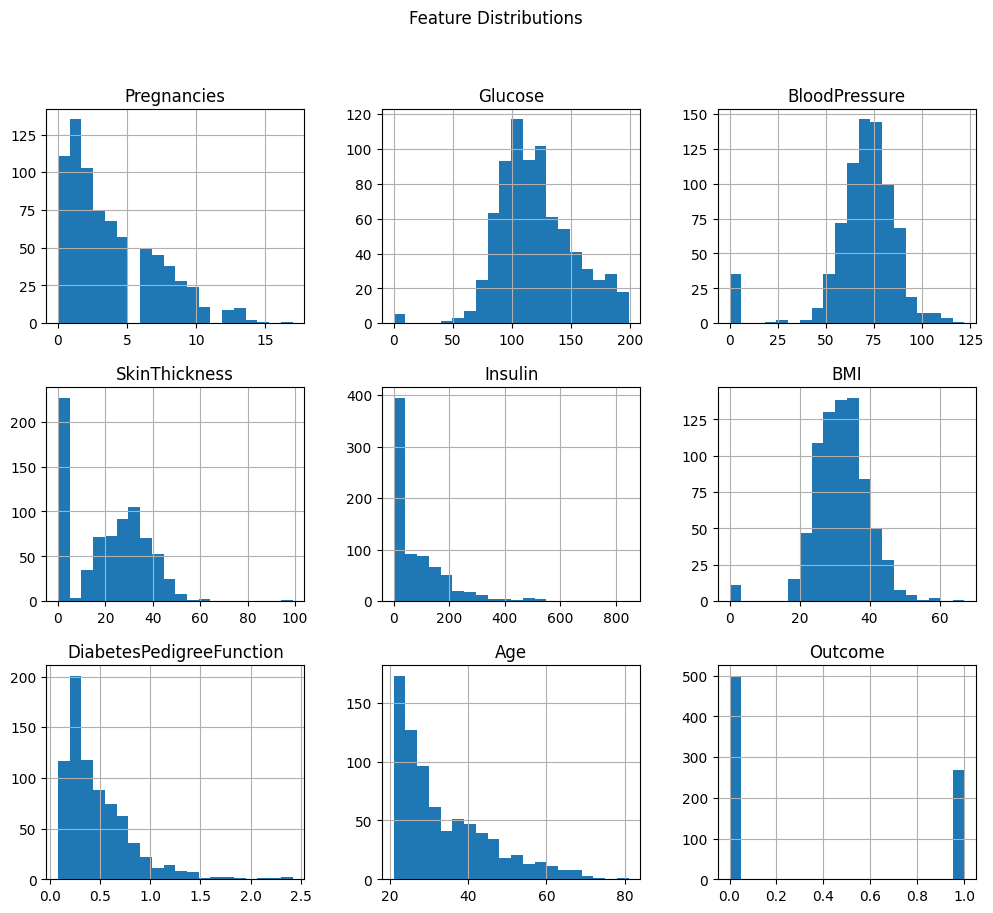

In [30]:
df.hist(figsize=(12,10), bins=20)
plt.suptitle("Feature Distributions")
plt.show()

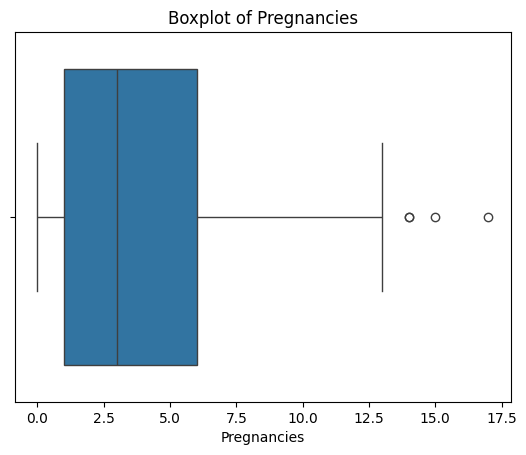

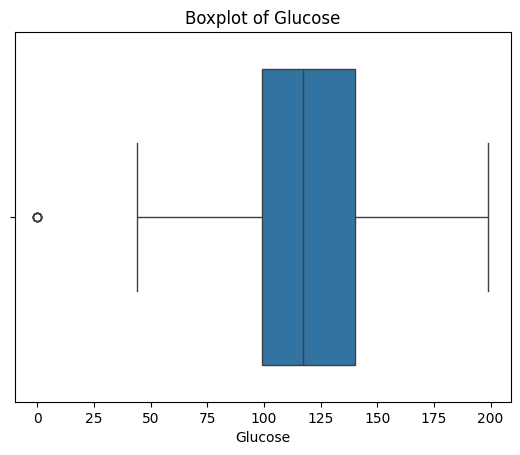

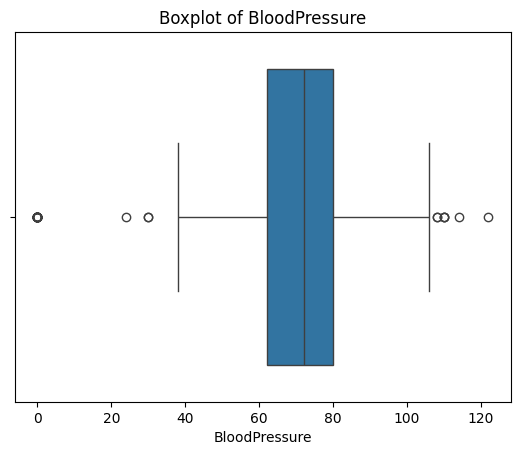

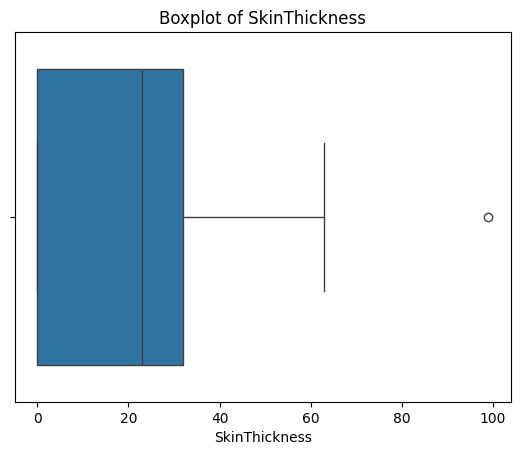

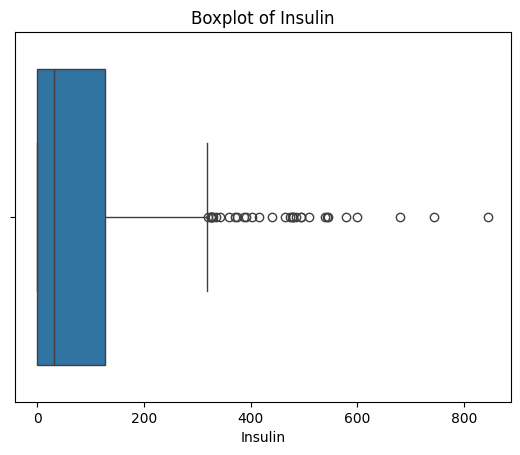

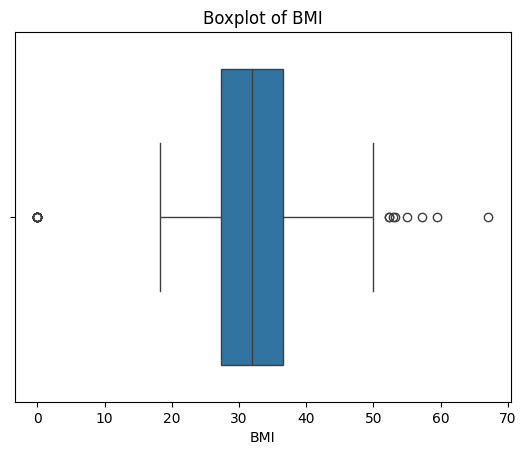

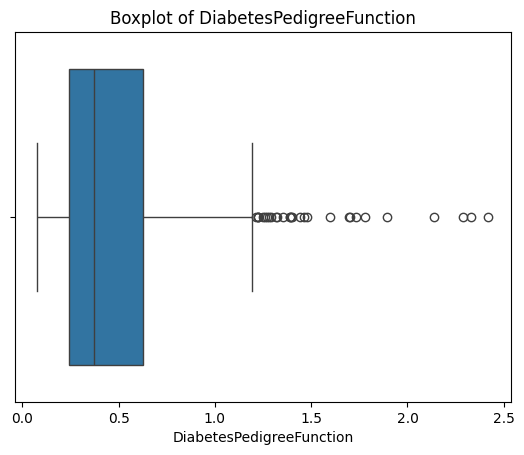

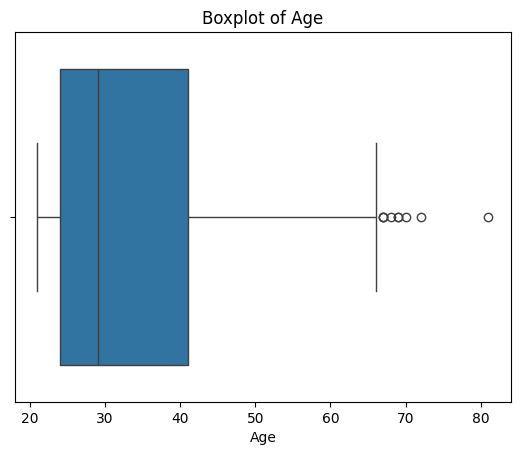

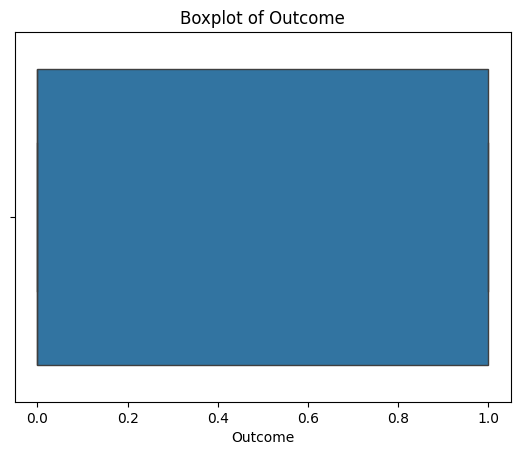

In [31]:
for col in df.columns:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [32]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

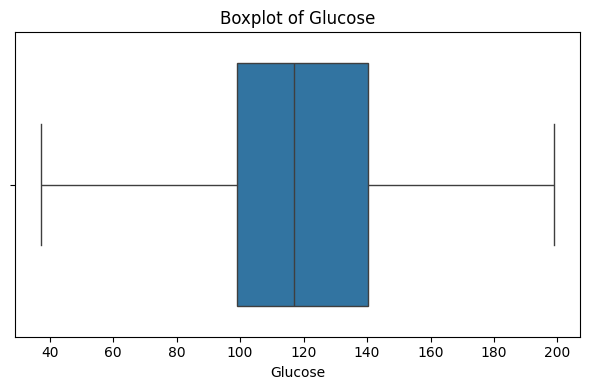

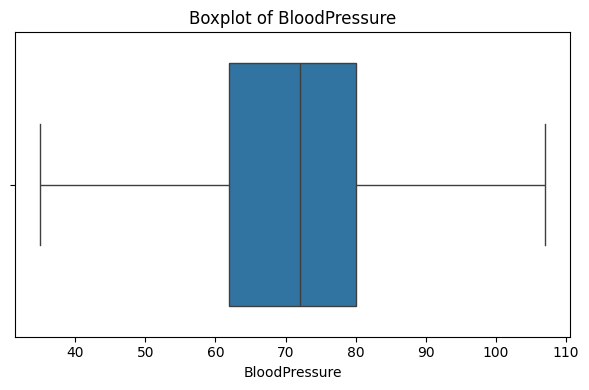

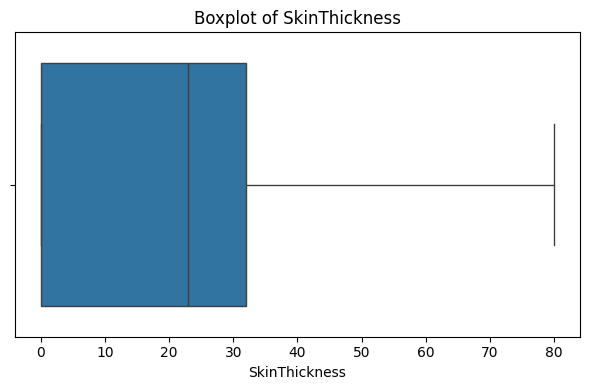

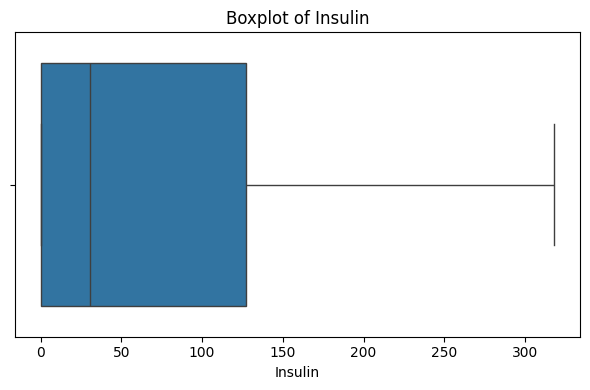

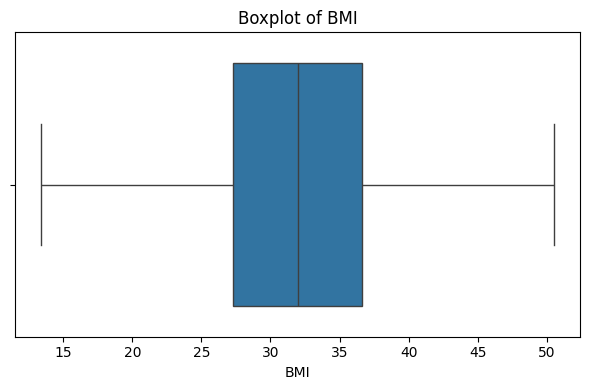

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI'
]

for col in cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [34]:
for col in df.columns:
    print(col, ":", (df[col] == 0).sum())

Pregnancies : 111
Glucose : 0
BloodPressure : 0
SkinThickness : 227
Insulin : 374
BMI : 0
DiabetesPedigreeFunction : 0
Age : 0
Outcome : 500


In [35]:
cols_to_fix = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols_to_fix:
    df[col] = df[col].replace(0, df[col].median())

In [36]:
for col in cols_to_fix:
    print(col, ":", (df[col] == 0).sum())

Glucose : 0
BloodPressure : 0
SkinThickness : 0
Insulin : 0
BMI : 0


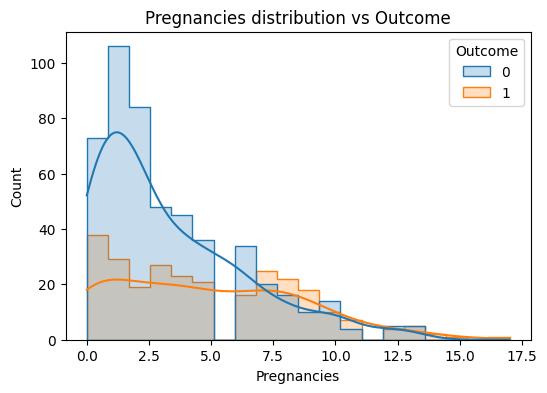

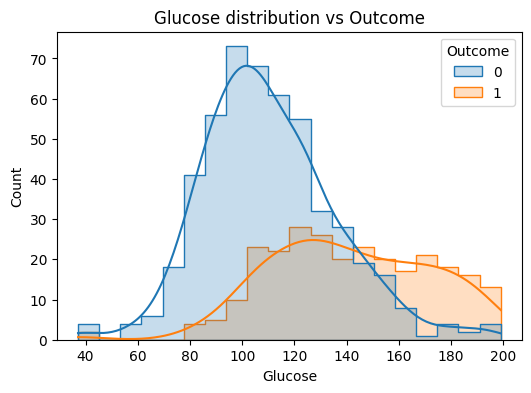

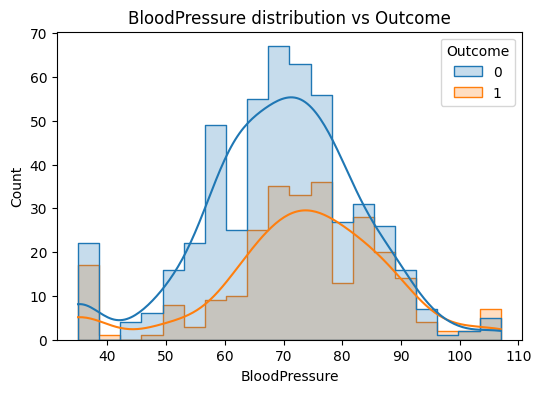

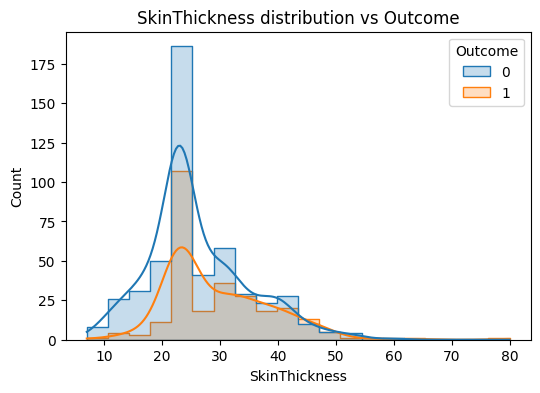

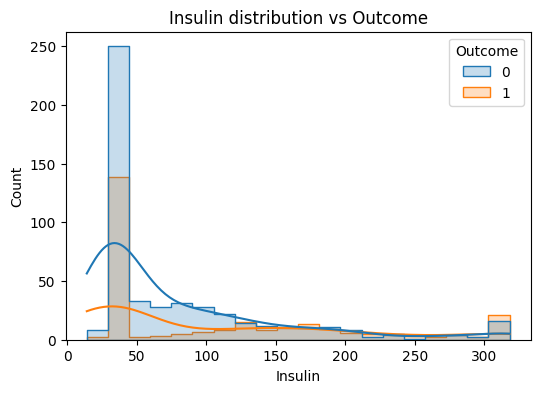

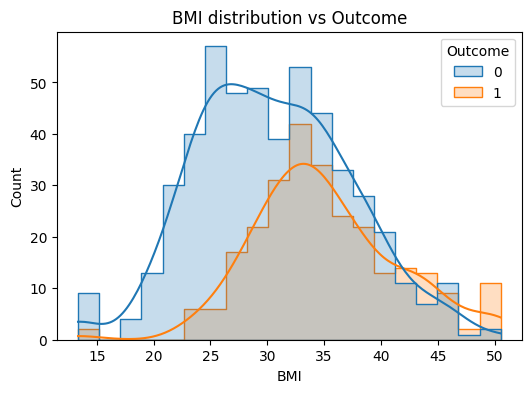

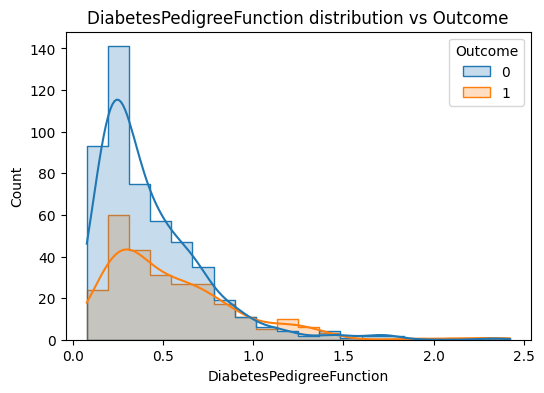

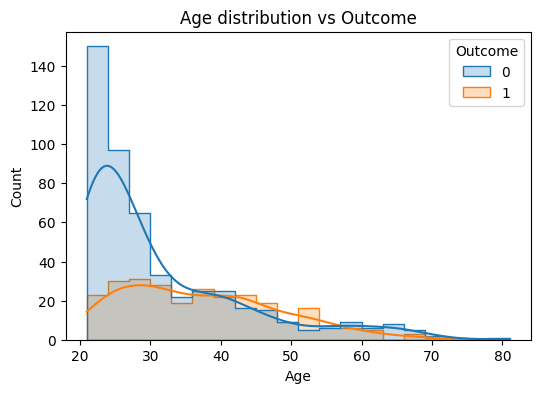

In [38]:
target = "Outcome"

for col in df.columns:
    if col != target:
        plt.figure(figsize=(6,4))
        sns.histplot(
            data=df,
            x=col,
            hue=target,
            bins=20,
            kde=True,
            element="step"
        )
        plt.title(f"{col} distribution vs {target}")
        plt.show()